# Lab 4
## Polynomial Regression using PyTorch
Aswin Singh Karki
ACE080BCT016

## Theory

Polynomial Regression is a supervised machine learning technique used to model non-linear relationships between input and output variables. Instead of fitting a straight line like linear regression, it fits a polynomial curve of degree n.

The general equation is:

y=w0​+w1x+w2​x2+⋯+wnxn+b

### Importing Library

This cell imports all the necessary Python libraries required for the experiment. PyTorch (`torch`, `torch.nn`) is used to build and train the regression model, Pandas is used for reading and managing the dataset, and Matplotlib is used to create graphs for visualizing the data and model predictions. These libraries provide the essential tools for implementing machine learning algorithms efficiently.

In [1]:
import torch
import matplotlib.pyplot as plt
import torch.nn as nn
import pandas as pd

### Load Dataset

In this cell, the dataset is loaded from a CSV file into a Pandas DataFrame. Loading the data is the first step in any machine learning task because it provides the input and output values that the model will learn from during training.

In [2]:
df = pd.read_csv('assignment-data2.csv')

### Display Dataset

This cell displays the first few rows of the dataset to verify that the data has been imported correctly. Inspecting the dataset helps identify the available features, understand the data structure, and detect any obvious errors before training the model.

In [3]:
df.head()

,x,y
0,-9.8,673.28
1,-9.6,646.12
2,-9.4,619.52
3,-9.2,593.48
4,-9.0,568.00


### Convert Data to PyTorch Tensors

Machine learning models in PyTorch require data in tensor format. This cell converts the input (x) and output (y) values from the DataFrame into PyTorch float32 tensors so that mathematical operations, automatic differentiation, and optimization can be performed efficiently.

In [4]:
X = torch.tensor(df['x'].values, dtype=torch.float32)
y = torch.tensor(df['y'].values, dtype=torch.float32)
print(f"X-Shape: {X.shape}")
print(f"y-Shape: {y.shape}")

X-Shape: torch.Size([99])
y-Shape: torch.Size([99])


### Import Train-Test Split

This cell imports the `train_test_split` function from Scikit-learn. The function is used to divide the dataset into training and testing sets, allowing the model to be evaluated on unseen data after training.

In [5]:
from sklearn.model_selection import train_test_split

### Split Dataset

The dataset is divided into training (70%) and testing (30%) subsets. The training data is used to teach the model the relationship between variables, while the testing data is used to evaluate how well the trained model performs on new, unseen samples. A fixed `random_state=42` ensures reproducibility.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

### Check Dataset Shapes

This cell prints the dimensions of the training and testing datasets. Checking the shapes confirms that the dataset has been divided correctly and ensures that the model receives the expected number of samples and features.

In [7]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

(torch.Size([69]), torch.Size([69]), torch.Size([30]), torch.Size([30]))

### Plotting the Nature of Training and Testing Set

This cell creates a scatter plot of the training and testing datasets. Visualization helps in understanding the distribution of data points and provides insight into the non-linear (curved) relationship that the model is expected to learn. Training data is shown in blue and testing data in red.

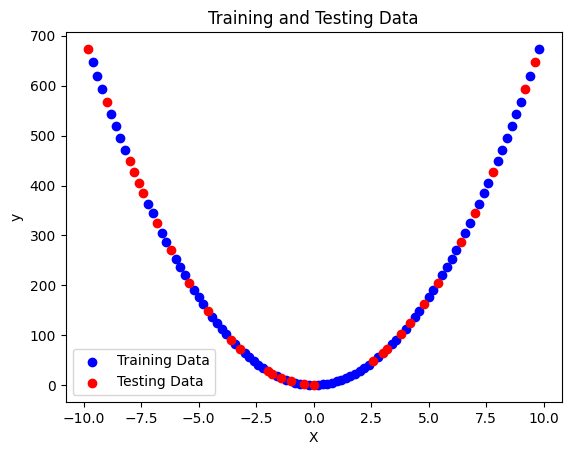

In [8]:
plt.scatter(X_train, y_train, label='Training Data', color='blue')
plt.scatter(X_test, y_test, label='Testing Data', color='red')
plt.title('Training and Testing Data')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()

### Define the Polynomial Regression Model

This cell defines a custom polynomial regression model by inheriting from PyTorch's `nn.Module` class. The model contains two learnable parameters — `weights` (w) and `bias` (b) — both initialized randomly. The `forward()` method defines how the prediction is computed: **ŷ = w·x + b + (3x)²**. The quadratic term `(3x)²` is a fixed non-linear feature added to allow the model to fit the curved pattern present in `assignment-data2.csv`. Both parameters have `requires_grad=True`, enabling PyTorch's autograd engine to compute gradients for optimization.

In [9]:
import torch.nn as nn

# Create a Polynomial Regression model class
class LinearRegressionModel(nn.Module):  # <- almost everything in PyTorch is a nn.Module
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(1,          # <- start with random weights
                                    dtype=torch.float),     # <- PyTorch loves float32 by default
                                    requires_grad=True)     # <- can we update this value with gradient descent?

        self.bias = nn.Parameter(torch.randn(1,             # <- start with random bias
                                dtype=torch.float),         # <- PyTorch loves float32 by default
                                requires_grad=True)         # <- can we update this value with gradient descent?

    # Forward defines the computation in the model
    def forward(self, x: torch.Tensor) -> torch.Tensor:    # <- 'x' is the input data
        return self.weights * x + self.bias + (3 * x) ** 2 # <- polynomial: y = wx + b + (3x)^2


### Initialize the Model

A manual random seed is set to ensure that results are reproducible across runs. An instance of the `LinearRegressionModel` is then created. At this point, the weight and bias parameters are randomly assigned and the model has not yet learned anything from the data.

In [10]:
# Set manual seed since nn.Parameter are randomly initialized
torch.manual_seed(42)

# Create an instance of the model
model_0 = LinearRegressionModel()

### Display Initial Parameters

This cell prints the initial values of the model's weight and bias. These values are randomly generated and will be updated during training to minimize the prediction error between the model's output and the true target values.

In [11]:
print(model_0.weights)
print(model_0.bias)

Parameter containing:
tensor([0.3367], requires_grad=True)
Parameter containing:
tensor([0.1288], requires_grad=True)


### Make Initial Predictions

The untrained model is used to generate predictions for the testing dataset using `torch.inference_mode()`, which disables gradient tracking for efficiency. Since the model has not learned from the data yet, these predictions are generally inaccurate and serve as a baseline for comparison against the trained model's output.

In [12]:
# Make predictions with model
with torch.inference_mode():
    y_preds = model_0(X_test)

y_preds[:5]

tensor([ 61.8442,  28.6828, 764.9863, 344.0013, 832.8011])

### Plotting the Initial Predictions

This cell plots the actual testing data (blue) alongside the model's initial predictions (red). The graph illustrates how far the untrained model's predictions deviate from the real values before any optimization has taken place. The poor fit is expected at this stage.

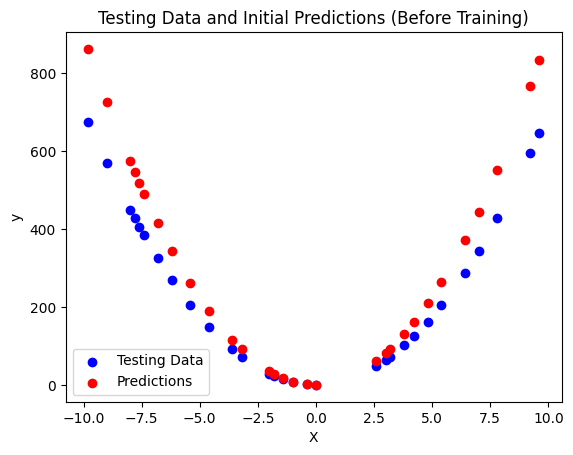

In [13]:
plt.scatter(X_test, y_test, label='Testing Data', color='blue')
plt.scatter(X_test, y_preds, label='Predictions', color='red')
plt.title('Testing Data and Initial Predictions (Before Training)')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()

### Define Loss Function and Optimizer

The **Mean Absolute Error (MAE)**, implemented as `nn.L1Loss()`, is selected as the loss function to measure the average magnitude of prediction errors. **Stochastic Gradient Descent (SGD)** is chosen as the optimizer to iteratively update the model's learnable parameters (weight and bias). The learning rate (`lr=0.01`) controls how large each parameter update step is — too high causes instability, too low causes slow convergence. Together, the loss function and optimizer guide the model toward better predictions during training.

In [14]:
# Loss Function Selection
loss_fn = nn.L1Loss()  # MAE loss is same as L1Loss

# Create the optimizer
optimizer = torch.optim.SGD(
    params=model_0.parameters(),  # parameters of target model to optimize
    lr=0.01)                       # learning rate

### Train the Model

This is the main training loop where the model learns from the data over multiple **epochs** (complete passes through the training set). Each epoch consists of five steps:

1. **Forward Pass** — the model computes predictions using the current weight and bias values.
2. **Loss Calculation** — the MAE loss measures how far predictions are from the true targets.
3. **Zero Gradients** — accumulated gradients from the previous step are cleared.
4. **Backward Pass** — PyTorch's autograd computes gradients of the loss with respect to each parameter.
5. **Parameter Update** — SGD adjusts the weight and bias in the direction that reduces the loss.

After each training step, the model is evaluated on the test set in `inference_mode()` to track generalization. Loss values are recorded every 10 epochs for later visualization. A total of **15,000 epochs** are used because the quadratic non-linear relationship in `data2` requires more iterations to converge compared to a purely linear dataset.

In [15]:
torch.manual_seed(42)

# Set the number of epochs
epochs = 15000

# Create empty loss lists to track values
train_loss_values = []
test_loss_values = []
epoch_count = []

for epoch in range(epochs):
    ### Training
    model_0.train()

    # 1. Forward pass on train data
    y_pred = model_0(X_train)

    # 2. Calculate the loss
    loss = loss_fn(y_pred, y_train)

    # 3. Zero grad of the optimizer
    optimizer.zero_grad()

    # 4. Loss backwards
    loss.backward()

    # 5. Progress the optimizer
    optimizer.step()

    ### Testing
    model_0.eval()

    with torch.inference_mode():
        test_pred = model_0(X_test)
        test_loss = loss_fn(test_pred, y_test.type(torch.float))

        if epoch % 10 == 0:
            epoch_count.append(epoch)
            train_loss_values.append(loss.detach().numpy())
            test_loss_values.append(test_loss.detach().numpy())
            print(f"Epoch: {epoch} | MAE Train Loss: {loss} | MAE Test Loss: {test_loss}")


Epoch: 0 | MAE Train Loss: 63.43925476074219 | MAE Test Loss: 67.06942749023438
Epoch: 10 | MAE Train Loss: 63.35624694824219 | MAE Test Loss: 67.01073455810547
Epoch: 20 | MAE Train Loss: 63.27616882324219 | MAE Test Loss: 66.95262908935547
Epoch: 30 | MAE Train Loss: 63.19906234741211 | MAE Test Loss: 66.89805603027344
Epoch: 40 | MAE Train Loss: 63.12259292602539 | MAE Test Loss: 66.84386444091797
Epoch: 50 | MAE Train Loss: 63.046112060546875 | MAE Test Loss: 66.78968811035156
Epoch: 60 | MAE Train Loss: 62.969627380371094 | MAE Test Loss: 66.73550415039062
Epoch: 70 | MAE Train Loss: 62.89680099487305 | MAE Test Loss: 66.68209075927734
Epoch: 80 | MAE Train Loss: 62.82631301879883 | MAE Test Loss: 66.6290054321289
Epoch: 90 | MAE Train Loss: 62.75580978393555 | MAE Test Loss: 66.575927734375
Epoch: 100 | MAE Train Loss: 62.68532180786133 | MAE Test Loss: 66.52284240722656
Epoch: 110 | MAE Train Loss: 62.61482238769531 | MAE Test Loss: 66.46976470947266
Epoch: 120 | MAE Train Loss:

### Plot Loss Curve

The recorded training and testing losses are plotted over epochs. A steadily decreasing loss curve for both training and testing sets indicates that the model is successfully learning the underlying pattern in the data. If the training loss continues to decrease but the test loss starts increasing, it is a sign of **overfitting** — the model has memorized the training data rather than generalized from it.

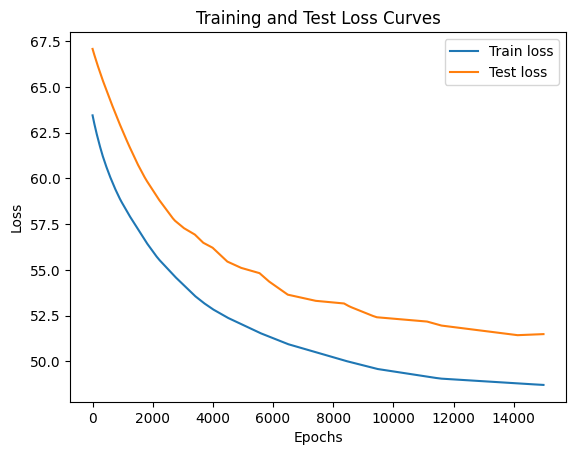

In [16]:
# Plot the loss curves
plt.plot(epoch_count, train_loss_values, label='Train loss')
plt.plot(epoch_count, test_loss_values, label='Test loss')
plt.title('Training and Test Loss Curves')
plt.ylabel('Loss')
plt.xlabel('Epochs')
plt.legend();

### Display Learned Parameters

After training, this cell prints the model's learned weight and bias values using `model_0.state_dict()`. Comparing these learned values to the known ground-truth parameters of the dataset helps verify that the optimizer has successfully found values that minimize the loss. Note that since the quadratic term `(3x)²` is fixed (not learnable), only `w` and `b` are updated during training.

In [17]:
print("The model learned the following values for weights and bias:")
print(model_0.state_dict())
print("\nAnd the original values for weights and bias are:")
print(f"weights: 0.7, bias: 0.3")

The model learned the following values for weights and bias:
OrderedDict({'weights': tensor([-1.1783]), 'bias': tensor([-39.2276])})

And the original values for weights and bias are:
weights: 0.7, bias: 0.3


### Plot Final Predictions

This final cell evaluates the trained model on the test set and visualizes the results. Training data (blue), testing data (red), and the model's final predictions (green) are plotted together. After training, the green prediction points should closely follow the curved pattern of the data, demonstrating that the polynomial regression model has successfully learned to fit the non-linear relationship in `assignment-data2.csv`.

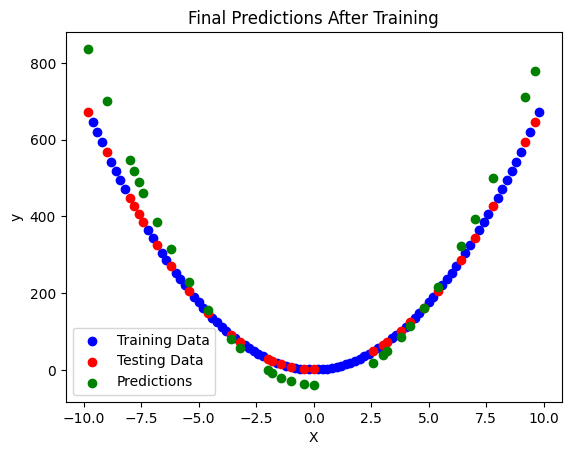

In [18]:
model_0.eval()

with torch.inference_mode():
    y_preds = model_0(X_test)

plt.scatter(X_train, y_train, label='Training Data', color='blue')
plt.scatter(X_test, y_test, label='Testing Data', color='red')
plt.scatter(X_test, y_preds, label='Predictions', color='green')
plt.title('Final Predictions After Training')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()